## Data Cleaning
* convert strings to numerics
* remove rows containing any NaN or null values
* add a column 'is_top100'

In [23]:
import numpy as np
import pandas as pd

df = pd.read_csv('timesData.csv')
df.dtypes
df.isnull().sum()

df['citations'] = pd.to_numeric(df['citations'], errors='coerce')
df['international'] = pd.to_numeric(df['international'], errors='coerce')
df['income'] = pd.to_numeric(df['income'], errors='coerce')
df.isnull().sum()

score_cols = ['teaching', 'international', 'research', 'citations', 'income']
df = df.dropna(subset=score_cols)

df['world_rank']=pd.to_numeric(df['world_rank'],errors='coerce')
df['is_top100'] = (df['world_rank'] <= 100).astype(int)

df.head()

,world_rank,university_name,country,teaching,international,research,citations,income,total_score,num_students,student_staff_ratio,international_students,female_male_ratio,year,is_top100
0,1.0,Harvard University,United States of America,99.7,72.4,98.7,98.8,34.5,96.1,"20,152",8.9,25%,NaN,2011,1
1,2.0,California Institute of Technology,United States of America,97.7,54.6,98.0,99.9,83.7,96.0,"2,243",6.9,27%,33 : 67,2011,1
2,3.0,Massachusetts Institute of Technology,United States of America,97.8,82.3,91.4,99.9,87.5,95.6,"11,074",9.0,33%,37 : 63,2011,1
3,4.0,Stanford University,United States of America,98.3,29.5,98.1,99.2,64.3,94.3,"15,596",7.8,22%,42 : 58,2011,1
5,6.0,University of Cambridge,United Kingdom,90.5,77.7,94.1,94.0,57.0,91.2,"18,812",11.8,34%,46 : 54,2011,1


## Feature Engineering
- Add binary label: is_top100 (1 = top-100, 0 = otherwise)
- Define feature matrix X of 5 columns and target y

In [24]:

X = df[['teaching','research','citations','international','income']]
y = df['is_top100']

# Classification
* split the train and test data with 80/20, random_state=42
* Use Pipeline to fit on train samples to prevents data leakage
* three models: LogisticRegression, DecisionTreeClassifier and RandomForestClassifier
* compute their respective confusion matrices, classification reports, ROC-AUC values, as well ROC curves on one figure

[[373  10]
 [ 18  75]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       383
           1       0.88      0.81      0.84        93

    accuracy                           0.94       476
   macro avg       0.92      0.89      0.90       476
weighted avg       0.94      0.94      0.94       476

AUC of LogisticRegression: 0.988938487885679
[[370  13]
 [ 12  81]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       383
           1       0.86      0.87      0.87        93

    accuracy                           0.95       476
   macro avg       0.92      0.92      0.92       476
weighted avg       0.95      0.95      0.95       476

AUC of RandomForest: 0.9852326005783429
[[366  17]
 [ 16  77]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       383
           1       0.82      0.83      0.82        93

    accuracy                

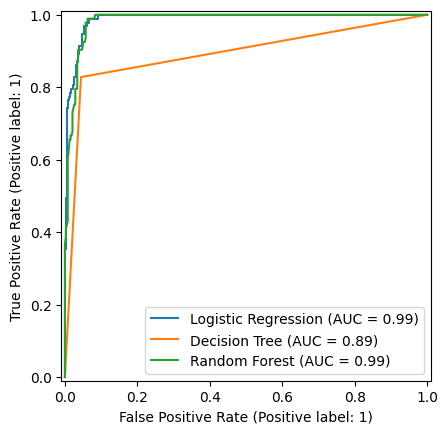

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

pipe_LogisticRegression = Pipeline([
    ('scaler',StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])
pipe_LogisticRegression.fit(X_train,y_train)

y_L_pred = pipe_LogisticRegression.predict(X_test)
y_L_prob = pipe_LogisticRegression.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_L_pred))
print(classification_report(y_test, y_L_pred))
print('AUC of LogisticRegression:', roc_auc_score(y_test, y_L_prob))

pipe_RandomForest= Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])
pipe_RandomForest.fit(X_train,y_train)

y_R_pred = pipe_RandomForest.predict(X_test)
y_R_prob = pipe_RandomForest.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_R_pred))
print(classification_report(y_test, y_R_pred))
print('AUC of RandomForest:', roc_auc_score(y_test, y_R_prob))

pipe_DecisionTree= Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])
pipe_DecisionTree.fit(X_train,y_train)

y_D_pred = pipe_DecisionTree.predict(X_test)
y_D_prob = pipe_DecisionTree.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_D_pred))
print(classification_report(y_test, y_D_pred))
print('AUC of DecisionTree:', roc_auc_score(y_test, y_D_prob))

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_L_prob, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_D_prob, name='Decision Tree', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_R_prob, name='Random Forest', ax=ax)
plt.show()



# PCA and KMeans
* scale the data and apply PCA
* plot explained_variance, revealing that top three principle components contains ~90% information, which connects to what we drew from Project 1: Gram matrix, which asserted ~3–4 effective dimensions, is proportional to the PCA covariance matrix. This is because they are measuring the same geometric fact
* scatter plot PC1 vs PC2, colored by is_top100
* K-means with k=2,3,4, with adjusted random score computed. Note that clusters do not completely align with top-100 boundary

[0.51047778 0.22352204 0.15416619 0.09662793 0.01520606]


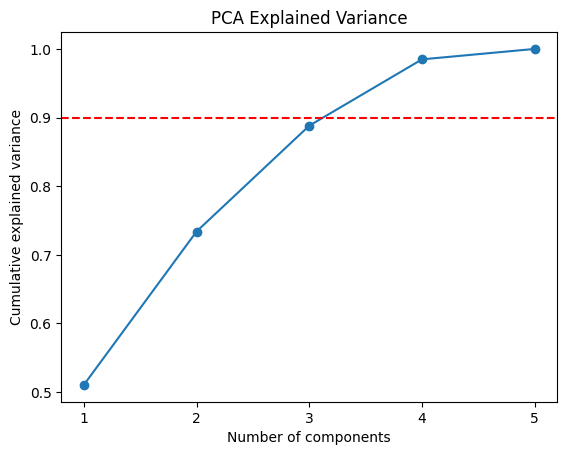

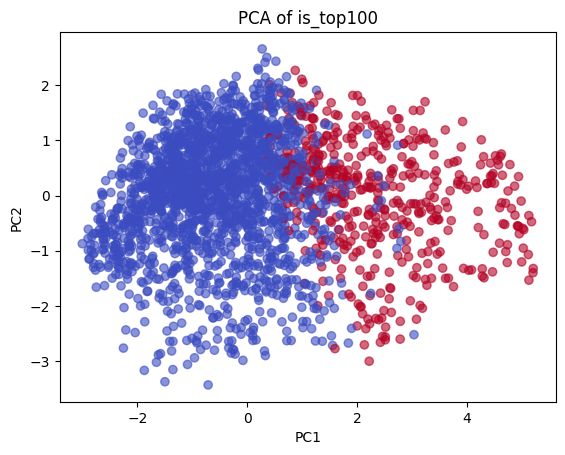

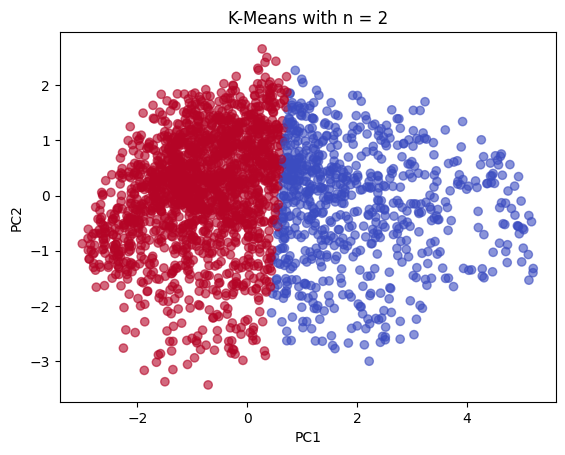

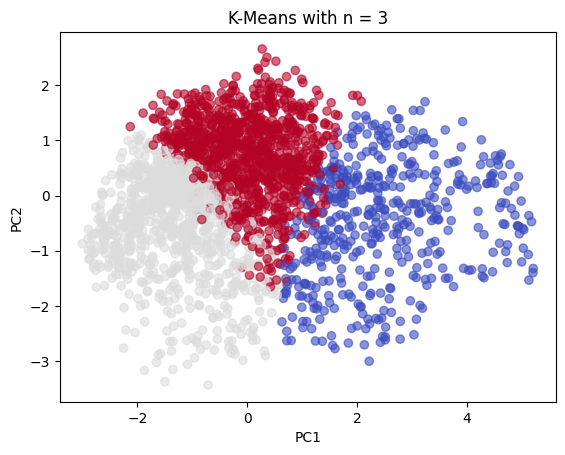

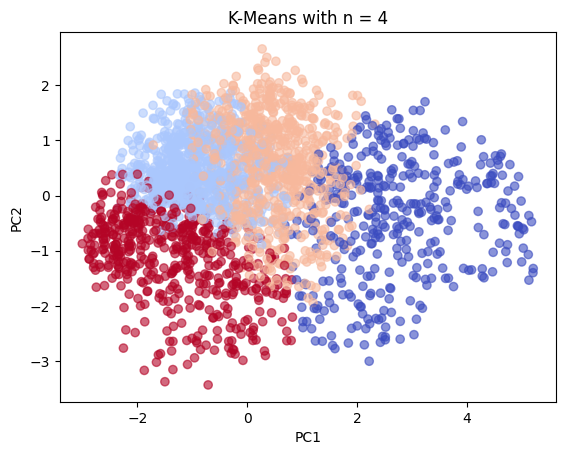

ARI k=2: 0.6073143945091464
ARI k=3: 0.25309347025604223
ARI k=4: 0.17193091840904992


In [63]:
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components= 5)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
plt.plot(range(1, 6), np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.xticks(range(1, 6))
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of is_top100")
plt.show()

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans2 = KMeans(n_clusters = 2, random_state=42)
kmeans2.fit(X_scaled)
labels2 = kmeans2.labels_

kmeans3 = KMeans(n_clusters = 3, random_state=42)
kmeans3.fit(X_scaled)
labels3 = kmeans3.labels_

kmeans4 = KMeans(n_clusters = 4, random_state=42)
kmeans4.fit(X_scaled)
labels4 = kmeans4.labels_

plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels2, cmap = 'coolwarm', alpha = 0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means with n = 2")
plt.show()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels3, cmap = 'coolwarm', alpha = 0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means with n = 3")
plt.show()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = labels4, cmap = 'coolwarm', alpha = 0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means with n = 4")
plt.show()

print('ARI k=2:', adjusted_rand_score(y, labels2))
print('ARI k=3:', adjusted_rand_score(y, labels3))
print('ARI k=4:', adjusted_rand_score(y, labels4))
